# Práctica: Clasificación en el Juego del Ultimátum con XAI y Blockchain

En esta práctica trabajarás con datos fisiológicos (frecuencia cardíaca, conductancia galvánica y EEG) capturados durante el Juego del Ultimátum. Primero correrás un ejemplo ya resuelto que muestra el pipeline completo: entrenamiento de un modelo Random Forest, explicabilidad con SHAP y registro en blockchain. Después, con un segundo dataset de features fisiológicas corregidas por baseline, elegirás tus propias features, entrenarás el modelo, analizarás qué señales son más relevantes para predecir si un participante acepta o rechaza una oferta, y compararás tus resultados con el ejemplo

Este notebook tiene dos partes:

- **Parte 1 (ejemplo)**: Modelo V1 con features crudas de ejemplo
- **Parte 2**: Modelo 2 con features fisiológicas de detección de enojo —
    eleccion de features, interpretas SHAP y escribes conclusiones.
- **Parte 3**: Comparación de ambos modelos.

### Configuración

| Elemento | Valor |
|----------|------|
| Modelo | Random Forest (mismos hiperparámetros) |
| Validación | LOSO, 4 folds |
| XAI | SHAP TreeExplainer |


**Ciencia de Datos para Sensores Inteligentes/Tópicos Selectos en Sistemas Interactivos 2026**

**Estudiante:** Leon-Altamirano F. Z. C.

In [ ]:
!pip install -q web3 shap eth_account


---
## 0. Setup


In [1]:
import hashlib, json, os, sys, io, warnings, pickle, platform
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report,
)

import shap

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

# --- Chain logger (blockchain) ---
from xai_chain_logger import chain_logger, Stage, get_chain_logger

# --- Configuración fija para todos ---
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

FEATURES_DIR = Path(".")

# --- Utilidades ---
def sha256_bytes(b: bytes) -> str:
    return hashlib.sha256(b).hexdigest()

def sha256_text(s: str) -> str:
    return sha256_bytes(s.encode('utf-8'))

def json_stable(obj) -> str:
    return json.dumps(obj, sort_keys=True, ensure_ascii=False, separators=(',',':'), default=str)

def df_hash(df):
    buf = io.StringIO()
    df.to_csv(buf, index=False, float_format='%.10g')
    return sha256_bytes(buf.getvalue().encode('utf-8'))

def safe_register(stage, payload):
    """Registra en blockchain. Si no hay gas, guarda el payload localmente."""
    try:
        ok, tx_hash, record = chain_logger.register(stage=stage, payload=payload)
        print(f"  [ON-CHAIN] OK | TX: {tx_hash}")
        return tx_hash
    except Exception as e:
        msg = str(e)
        if 'insufficient funds' in msg:
            print(f"  [ON-CHAIN] SKIP — Sin gas en Sepolia")
        else:
            print(f"  [ON-CHAIN] ERROR: {msg[:120]}")
        pending = {"stage": stage.value, "payload": payload}
        path = OUTPUT_DIR / f"pending_{stage.value}.json"
        with open(path, 'w') as f:
            json.dump(pending, f, indent=2, default=str)
        print(f"  [OFF-CHAIN] Guardado en {path}")
        return None

ALL_TX = {}

print(f"Chain logger: {'OK' if chain_logger else 'NO DISPONIBLE'}")


Chain logger: OK


---
---
# PARTE 1 (Ejemplo) — Dataset V1: Features Crudas


In [2]:
DATASET_VERSION = "V1_raw"
OUTPUT_DIR = Path("output_v1_raw")
OUTPUT_DIR.mkdir(exist_ok=True)
ALL_TX = {}


---
## 1. Carga del dataset V1

In [3]:
df_full = pd.read_csv(Path("dataset_A_naive.csv"))

CLEAN_PARTICIPANTS = ["P001", "P003", "P004", "P005"]

df = df_full[
    (df_full["participant_id"].isin(CLEAN_PARTICIPANTS)) &
    (df_full["decision"].isin(["accept", "reject"]))
].copy()
df["label"] = (df["decision"] == "accept").astype(int)

print(f"Participantes: {sorted(df['participant_id'].unique().tolist())}")
print(f"Trials: {len(df)} (accept={df['label'].sum()}, reject={int((1-df['label']).sum())})")
print(f"\nColumnas disponibles ({len(df.columns)}):")
print(df.columns.tolist())
print()
df.describe().T


Participantes: ['P001', 'P003', 'P004', 'P005']
Trials: 95 (accept=29, reject=66)

Columnas disponibles (25):
['participant_id', 'trial_number', 'offer_amount', 'offer_category', 'decision', 'decision_time_s', 'mean_hr', 'hr_std', 'mean_rr_ms', 'rmssd', 'sdnn', 'pnn50', 'mean_gsr', 'max_gsr', 'gsr_std', 'ecg_amplitude_range', 'ecg_std', 'mean_eeg_tp9', 'mean_eeg_af7', 'mean_eeg_af8', 'mean_eeg_tp10', 'gsr_reliable', 'hr_reliable', 'eeg_available', 'label']



,count,mean,std,min,25%,50%,75%,max
trial_number,95.0,12.621053,6.893072,1.000000,7.000000,13.000000,18.500000,24.000000
offer_amount,95.0,2.568421,1.407825,0.500000,1.500000,3.000000,3.500000,5.000000
decision_time_s,95.0,0.000053,0.006612,-0.012500,-0.005500,0.000000,0.005000,0.013000
mean_hr,95.0,88.373253,24.784108,37.669643,70.784722,77.818182,108.627976,136.384615
hr_std,95.0,4.341969,2.485515,0.868115,2.225410,3.876338,5.865343,13.578086
mean_rr_ms,95.0,737.025499,207.281487,440.346154,571.270000,789.730769,850.564103,1655.076190
rmssd,94.0,41.503234,36.089740,4.538722,23.589935,32.844256,57.212112,215.830518
sdnn,94.0,52.341089,45.756307,4.591659,29.248012,42.265560,66.415867,308.004610
pnn50,94.0,16.936596,17.537955,0.000000,0.000000,11.538462,27.355072,75.000000
mean_gsr,95.0,21310.505708,5716.382597,12024.712857,15616.915833,22395.600769,26992.485144,28458.650000


### Features seleccionadas para este ejemplo

En este ejemplo usamos **todas las features V1** disponibles.
En la parte 2 tú elegirás cuáles usar.


In [4]:
FEATURE_COLS = [
    "offer_amount", "decision_time_s",
    "mean_hr", "hr_std",
    "rmssd", "sdnn", "pnn50",
    "mean_gsr", "max_gsr", "gsr_std",
    "mean_eeg_af7", "mean_eeg_af8",
]

print(f"Features seleccionadas ({len(FEATURE_COLS)}): {FEATURE_COLS}")

# Missingness check
print(f"\nMissingness:")
for col in FEATURE_COLS:
    miss = df[col].isna().sum()
    pct = miss / len(df) * 100
    print(f"  {col:20s}: {miss:3d}/{len(df)} ({pct:.1f}%)")


Features seleccionadas (12): ['offer_amount', 'decision_time_s', 'mean_hr', 'hr_std', 'rmssd', 'sdnn', 'pnn50', 'mean_gsr', 'max_gsr', 'gsr_std', 'mean_eeg_af7', 'mean_eeg_af8']

Missingness:
  offer_amount        :   0/95 (0.0%)
  decision_time_s     :   0/95 (0.0%)
  mean_hr             :   0/95 (0.0%)
  hr_std              :   0/95 (0.0%)
  rmssd               :   1/95 (1.1%)
  sdnn                :   1/95 (1.1%)
  pnn50               :   1/95 (1.1%)
  mean_gsr            :   0/95 (0.0%)
  max_gsr             :   0/95 (0.0%)
  gsr_std             :   0/95 (0.0%)
  mean_eeg_af7        :   0/95 (0.0%)
  mean_eeg_af8        :   0/95 (0.0%)


In [5]:
# EDA: valores promedio por clase para tus features
print("Accept vs Reject — valores crudos:")
print("=" * 75)
for col in FEATURE_COLS:
    acc = df[df['decision']=='accept'][col].mean()
    rej = df[df['decision']=='reject'][col].mean()
    delta = acc - rej
    print(f"  {col:20s}: accept={acc:10.2f}  reject={rej:10.2f}  diff={delta:+.2f}")


Accept vs Reject — valores crudos:
  offer_amount        : accept=      4.24  reject=      1.83  diff=+2.41
  decision_time_s     : accept=      0.00  reject=     -0.00  diff=+0.00
  mean_hr             : accept=     92.93  reject=     86.37  diff=+6.56
  hr_std              : accept=      3.65  reject=      4.65  diff=-1.00
  rmssd               : accept=     33.42  reject=     44.93  diff=-11.51
  sdnn                : accept=     40.80  reject=     57.24  diff=-16.44
  pnn50               : accept=     13.95  reject=     18.20  diff=-4.25
  mean_gsr            : accept=  21706.46  reject=  21136.52  diff=+569.94
  max_gsr             : accept=  22349.99  reject=  22018.84  diff=+331.15
  gsr_std             : accept=    518.91  reject=    748.97  diff=-230.05
  mean_eeg_af7        : accept=    730.61  reject=    729.44  diff=+1.17
  mean_eeg_af8        : accept=    727.28  reject=    729.35  diff=-2.07


In [6]:
# Guardar dataset limpio
clean_path = OUTPUT_DIR / "dataset_v1_clean.csv"
df.to_csv(clean_path, index=False)
dataset_sha256 = df_hash(df)
print(f"Dataset SHA-256: {dataset_sha256}")

Dataset SHA-256: 7b259344114c36730e383aa4d0c43c54a8f8142cb01450a0ec283edaeea81689


### >>> REGISTRO ON-CHAIN: DATASET_INGEST <<<

> Corre esta celda **solo cuando hayas terminado de explorar** el dataset.
> Registra el hash del CSV + metadata en Ethereum Sepolia.

In [7]:
ingest_payload = {
    "dataset_version": DATASET_VERSION,
    "dataset_sha256": dataset_sha256,
    "n_rows": len(df),
    "n_features": len(FEATURE_COLS),
    "features": FEATURE_COLS,
    "participants": len(CLEAN_PARTICIPANTS),
    "class_balance": {"accept": int(df['label'].sum()), "reject": int((1-df['label']).sum())},
}

print("Payload DATASET_INGEST:")
print(json_stable(ingest_payload))
print()
ALL_TX["dataset_ingest"] = safe_register(Stage.DATASET_INGEST, ingest_payload)

Payload DATASET_INGEST:
{"class_balance":{"accept":29,"reject":66},"dataset_sha256":"7b259344114c36730e383aa4d0c43c54a8f8142cb01450a0ec283edaeea81689","dataset_version":"V1_raw","features":["offer_amount","decision_time_s","mean_hr","hr_std","rmssd","sdnn","pnn50","mean_gsr","max_gsr","gsr_std","mean_eeg_af7","mean_eeg_af8"],"n_features":12,"n_rows":95,"participants":4}

[web3] Sent tx: 1c26149b02587ccf71d427ee6a7e61e97db598ba614d94f104ffcc00a0fddf89
  [ON-CHAIN] OK | TX: 1c26149b02587ccf71d427ee6a7e61e97db598ba614d94f104ffcc00a0fddf89


---
## 2. Preprocessing

Pipeline fijo: imputación con mediana (para los NaN de sensores) + estandarización z-score.
Todos los equipos usan el mismo pipeline para que los resultados sean comparables.

In [8]:
X_raw = df[FEATURE_COLS].values
y = df["label"].values
groups = df["participant_id"].values
feature_names = FEATURE_COLS

preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
preprocessor.fit(X_raw)
X = preprocessor.transform(X_raw)

scaler = preprocessor.named_steps["scaler"]
imputer = preprocessor.named_steps["imputer"]

scaler_state = {"mean": scaler.mean_.tolist(), "scale": scaler.scale_.tolist()}
X_sha256 = sha256_bytes(X.tobytes())

print(f"X shape: {X.shape}")
print(f"X SHA-256: {X_sha256}")

X shape: (95, 12)
X SHA-256: 0297e499c4f12e684f884528fc1ae2c372a4c29daf7085d3a9df33820f9a227d


### >>> REGISTRO ON-CHAIN: PREPROCESSING <<<

In [9]:
preproc_payload = {
    "pipeline": "SimpleImputer(median)+StandardScaler",
    "scaler_sha256": sha256_text(json_stable(scaler_state)),
    "X_sha256": X_sha256,
    "n_samples": len(X),
    "n_features": X.shape[1],
}
print("Payload PREPROCESSING:")
print(json_stable(preproc_payload))
print()
ALL_TX["preprocessing"] = safe_register(Stage.PREPROCESSING, preproc_payload)

Payload PREPROCESSING:
{"X_sha256":"0297e499c4f12e684f884528fc1ae2c372a4c29daf7085d3a9df33820f9a227d","n_features":12,"n_samples":95,"pipeline":"SimpleImputer(median)+StandardScaler","scaler_sha256":"dc8a784ade8ab29db364f6c1499b427393e24b4a79d1da35a83875fce7ba143a"}

[web3] Sent tx: 993237f445bfed8d22cddd4d20ccf4f771efe734b2dbfca773b38a2e08691769
  [ON-CHAIN] OK | TX: 993237f445bfed8d22cddd4d20ccf4f771efe734b2dbfca773b38a2e08691769


---
## 3. Entrenamiento — Random Forest + LOSO

El modelo y los hiperparámetros están fijos para todos. Lo que cambia son las features
que elegiste arriba.

**Ejecuta las siguientes celdas** para entrenar con tus features y ver los resultados.


In [10]:
# --- Hiperparámetros ---
HYPERPARAMS = {
    "n_estimators": 200,
    "max_depth": 4,
    "min_samples_split": 2,
    "min_samples_leaf": 1,
    "random_state": RANDOM_SEED,
    "n_jobs": -1,
}

logo = LeaveOneGroupOut()
rf = RandomForestClassifier(**HYPERPARAMS)

y_pred = cross_val_predict(rf, X, y, cv=logo, groups=groups)
y_proba = cross_val_predict(rf, X, y, cv=LeaveOneGroupOut(), groups=groups,
                             method="predict_proba")[:, 1]

try:
    auc = float(roc_auc_score(y, y_proba))
except:
    auc = None

metrics = {
    "accuracy": float(accuracy_score(y, y_pred)),
    "precision": float(precision_score(y, y_pred, zero_division=0)),
    "recall": float(recall_score(y, y_pred, zero_division=0)),
    "f1_macro": float(f1_score(y, y_pred, average="macro")),
    "roc_auc": auc,
}

print("METRICAS LOSO — Dataset V1 (Raw)")
print("=" * 50)
for k, v in metrics.items():
    print(f"  {k:15s}: {v:.4f}" if v else f"  {k:15s}: N/A")

print(f"\n{classification_report(y, y_pred, target_names=['reject','accept'])}")

# Por participante
print("Por participante:")
for pid in CLEAN_PARTICIPANTS:
    mask = groups == pid
    acc = accuracy_score(y[mask], y_pred[mask])
    print(f"  {pid}: acc={acc:.3f} (n={mask.sum()})")

METRICAS LOSO — Dataset V1 (Raw)
  accuracy       : 0.9474
  precision      : 1.0000
  recall         : 0.8276
  f1_macro       : 0.9346
  roc_auc        : 0.9687

              precision    recall  f1-score   support

      reject       0.93      1.00      0.96        66
      accept       1.00      0.83      0.91        29

    accuracy                           0.95        95
   macro avg       0.96      0.91      0.93        95
weighted avg       0.95      0.95      0.95        95

Por participante:
  P001: acc=1.000 (n=24)
  P003: acc=0.833 (n=24)
  P004: acc=0.957 (n=23)
  P005: acc=1.000 (n=24)


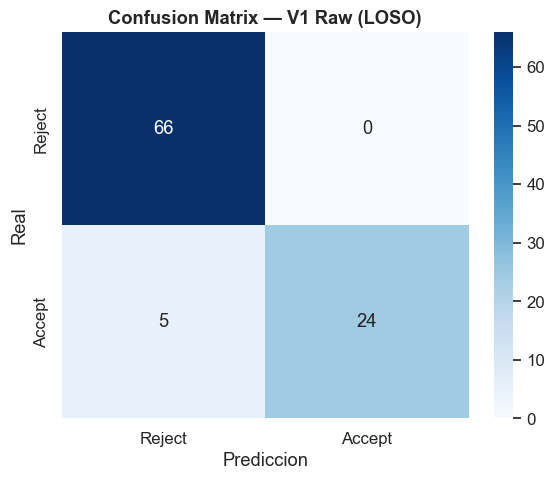

In [11]:
# Confusion matrix
cm = confusion_matrix(y, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Reject','Accept'], yticklabels=['Reject','Accept'], ax=ax)
ax.set_xlabel('Prediccion'); ax.set_ylabel('Real')
ax.set_title(f'Confusion Matrix — V1 Raw (LOSO)', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix_v1.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Modelo final (entrenado en todos los datos, para SHAP)
model_final = RandomForestClassifier(**HYPERPARAMS)
model_final.fit(X, y)

bundle = pickle.dumps({"preprocessor": preprocessor, "model": model_final,
                        "features": FEATURE_COLS, "hyperparams": HYPERPARAMS})
bundle_sha256 = sha256_bytes(bundle)
with open(OUTPUT_DIR / "model_v1.pkl", "wb") as f:
    f.write(bundle)
print(f"Bundle SHA-256: {bundle_sha256}")

Bundle SHA-256: 26d584cc331c4a803f8dfa07f09cfc87dfef3505f2a487954a4ade2baa7d3510


### >>> REGISTRO ON-CHAIN: TRAINING <<<

In [13]:
train_payload = {
    "dataset_version": DATASET_VERSION,
    "model": "RandomForest",
    "hyperparams": HYPERPARAMS,
    "validation": "LOSO",
    "acc": round(metrics["accuracy"], 4),
    "f1": round(metrics["f1_macro"], 4),
    "auc": round(metrics["roc_auc"], 4) if metrics["roc_auc"] else None,
    "bundle_sha256": bundle_sha256,
}
print("Payload TRAINING:")
print(json_stable(train_payload))
print()
ALL_TX["training"] = safe_register(Stage.TRAINING, train_payload)

Payload TRAINING:
{"acc":0.9474,"auc":0.9687,"bundle_sha256":"26d584cc331c4a803f8dfa07f09cfc87dfef3505f2a487954a4ade2baa7d3510","dataset_version":"V1_raw","f1":0.9346,"hyperparams":{"max_depth":4,"min_samples_leaf":1,"min_samples_split":2,"n_estimators":200,"n_jobs":-1,"random_state":42},"model":"RandomForest","validation":"LOSO"}

[web3] Sent tx: c4963625693423c44c2829a2453cef04f276e8ff4a77fd366992483d8293cafc
  [ON-CHAIN] OK | TX: c4963625693423c44c2829a2453cef04f276e8ff4a77fd366992483d8293cafc


---
## 4. SHAP — Explicabilidad

Configuración fija: TreeExplainer con 80 samples de background.

In [14]:
bg_size = min(80, X.shape[0])
bg_idx = np.random.RandomState(RANDOM_SEED).choice(X.shape[0], size=bg_size, replace=False)
background = X[bg_idx]
bg_sha256 = sha256_bytes(background.tobytes())

explainer = shap.TreeExplainer(model_final, data=background, feature_names=feature_names)
explanation = explainer(X)
sv = explanation.values
if sv.ndim == 3:
    sv = sv[:, :, 1]

mean_shap = np.abs(sv).mean(axis=0)
shap_order = np.argsort(mean_shap)[::-1]

print("SHAP Feature Importance — V1 Raw:")
print("=" * 55)
shap_ranking = []
for rank, idx in enumerate(shap_order, 1):
    pct = mean_shap[idx] / mean_shap.sum() * 100
    print(f"  {rank:2d}. {feature_names[idx]:20s} {mean_shap[idx]:.4f} ({pct:.1f}%)")
    shap_ranking.append({"feature": feature_names[idx], "mean_abs_shap": round(float(mean_shap[idx]), 6)})

SHAP Feature Importance — V1 Raw:
   1. offer_amount         0.2107 (61.4%)
   2. sdnn                 0.0190 (5.5%)
   3. hr_std               0.0183 (5.3%)
   4. rmssd                0.0155 (4.5%)
   5. mean_hr              0.0137 (4.0%)
   6. gsr_std              0.0122 (3.5%)
   7. pnn50                0.0118 (3.4%)
   8. decision_time_s      0.0110 (3.2%)
   9. mean_eeg_af8         0.0090 (2.6%)
  10. max_gsr              0.0086 (2.5%)
  11. mean_eeg_af7         0.0070 (2.0%)
  12. mean_gsr             0.0065 (1.9%)


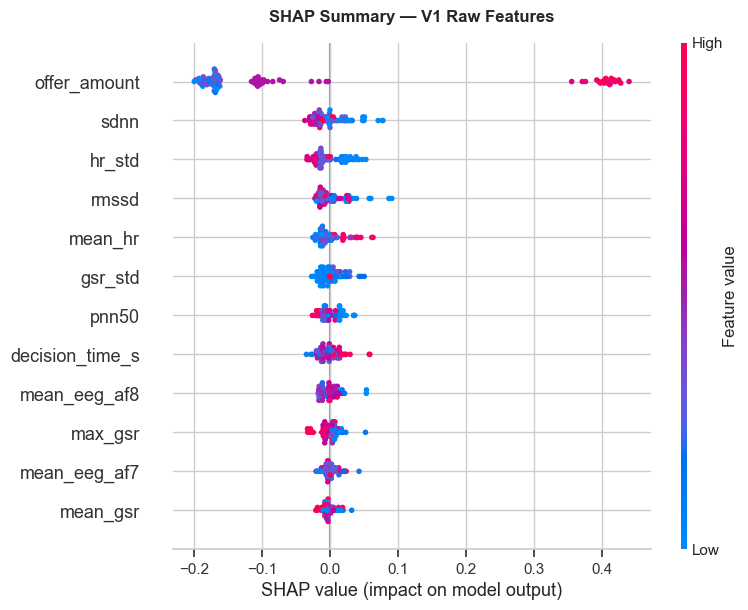

In [15]:
# Summary plot
plt.figure(figsize=(12, 7))
shap.summary_plot(sv, X, feature_names=feature_names, show=False)
plt.title('SHAP Summary — V1 Raw Features', fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'shap_summary_v1.png', dpi=150, bbox_inches='tight')
plt.show()

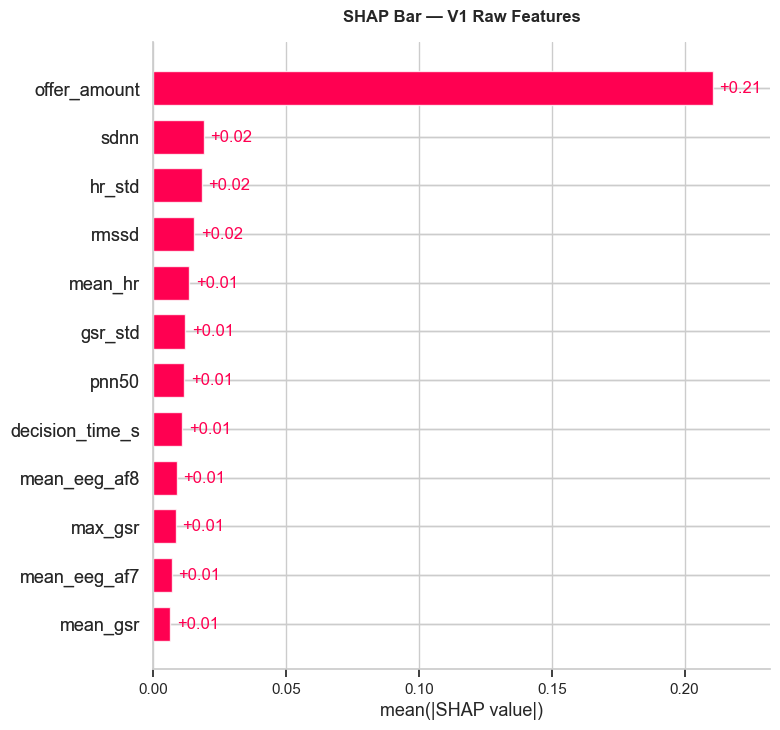

In [16]:
# Bar plot
plt.figure(figsize=(10, 6))
shap.plots.bar(shap.Explanation(values=sv, data=X, feature_names=feature_names),
               max_display=12, show=False)
plt.title('SHAP Bar — V1 Raw Features', fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'shap_bar_v1.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretación — SHAP global

En este ejemplo, las features con mayor impacto según SHAP suelen ser:

- **`offer_amount`**: el monto de la oferta es el predictor más fuerte. 
- **Features cardíacas** (`mean_hr`, `rmssd`, `sdnn`): capturan el estado autonómico del
  participante, aunque al ser valores absolutos mezclan la línea base con la respuesta.
- **`mean_gsr`**: la conductancia galvánica refleja arousal general, pero sin corrección
  por baseline es difícil separar el estado basal de la reacción al estímulo.

Nota cómo `offer_amount` domina. En la parte 2 verás si los sensores por sí solos pueden predecir.


### >>> REGISTRO ON-CHAIN: EXPLAINABILITY_SETUP <<<

In [17]:
xai_payload = {
    "type": "TreeExplainer",
    "bg_n": bg_size,
    "bg_sha256": bg_sha256,
    "top5_features": [r["feature"] for r in shap_ranking[:5]],
    "top5_shap": [r["mean_abs_shap"] for r in shap_ranking[:5]],
}
print("Payload EXPLAINABILITY_SETUP:")
print(json_stable(xai_payload))
print()
ALL_TX["explainability"] = safe_register(Stage.EXPLAINABILITY_SETUP, xai_payload)

Payload EXPLAINABILITY_SETUP:
{"bg_n":80,"bg_sha256":"f231905f73e5a5c97288e031bb792a15ee3945e73795792836f61c5805aa8143","top5_features":["offer_amount","sdnn","hr_std","rmssd","mean_hr"],"top5_shap":[0.210662,0.019011,0.018347,0.015456,0.013663],"type":"TreeExplainer"}

[web3] Sent tx: c4d05401aead78a912414d3e6130b7ea384f882b2f789b82d69390739f4f8ce0
  [ON-CHAIN] OK | TX: c4d05401aead78a912414d3e6130b7ea384f882b2f789b82d69390739f4f8ce0


---
## 5. Waterfall — Casos individuales

Los waterfall plots muestran la contribución de cada feature para un trial específico.
Es la versión "local" de SHAP: en vez del ranking global, ves qué empujó la predicción
de ese caso en particular.



Reject correcto: P001 T02
  Real: reject | Pred: reject
    1. offer_amount        : -0.1699
    2. sdnn                : -0.0213
    3. hr_std              : -0.0204


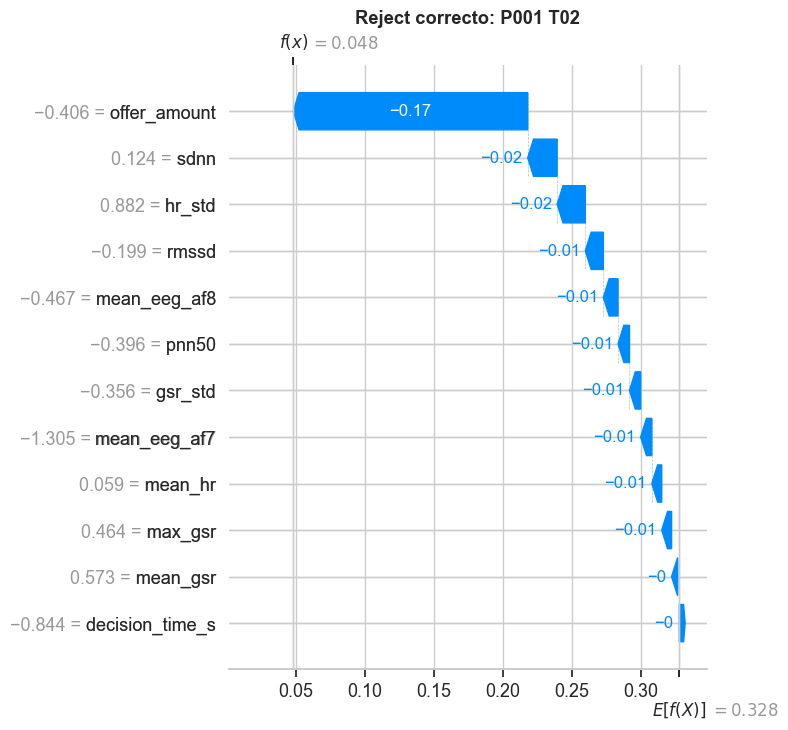


Accept correcto: P001 T01
  Real: accept | Pred: accept
    1. offer_amount        : +0.4391
    2. mean_hr             : +0.0302
    3. sdnn                : +0.0226


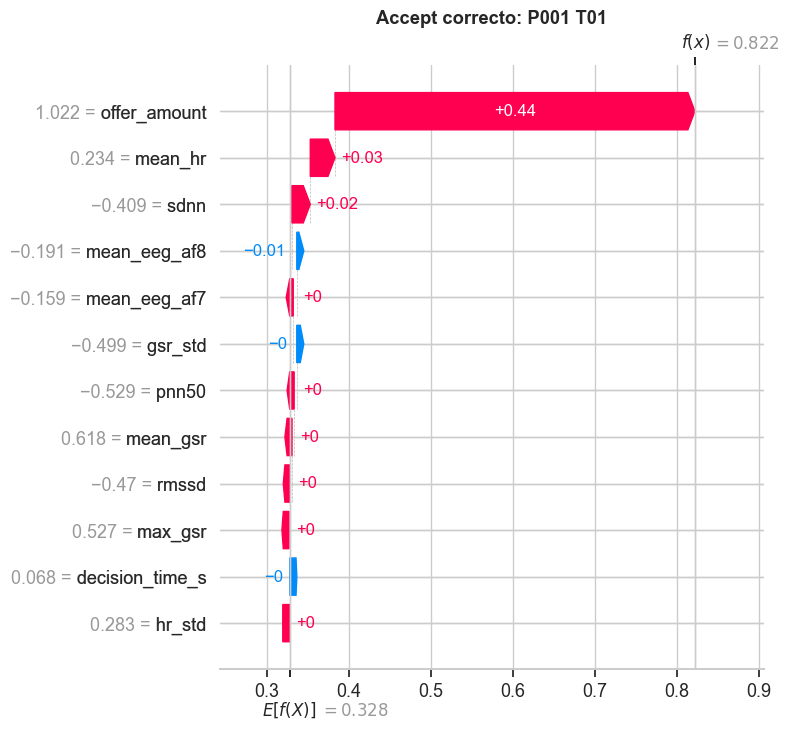


Misclassified: P003 T10
  Real: accept | Pred: reject
    1. rmssd               : +0.0576
    2. hr_std              : +0.0528
    3. sdnn                : +0.0506


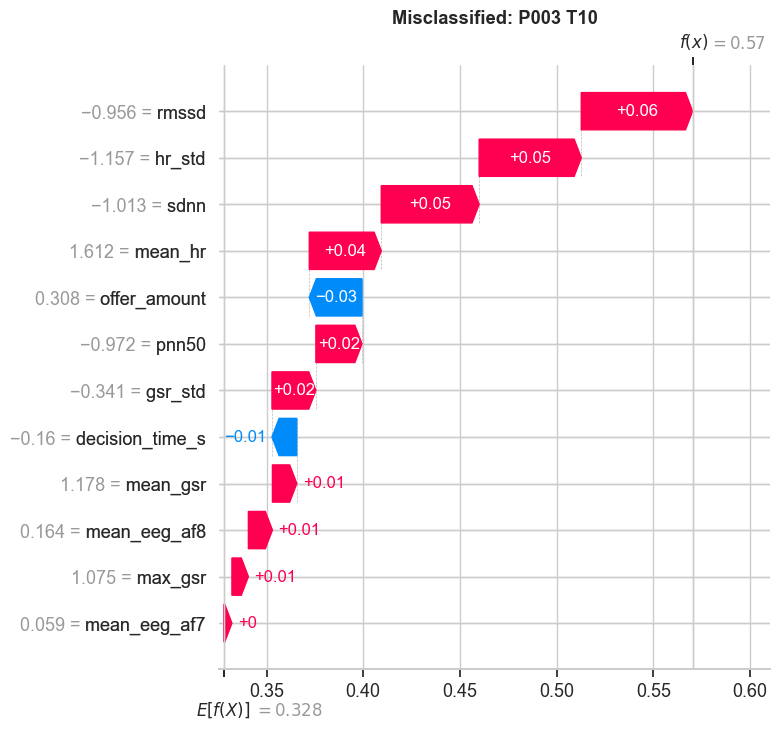

In [18]:
# Waterfall de 3 casos representativos
correct_rej = np.where((y == 0) & (y_pred == 0))[0]
correct_acc = np.where((y == 1) & (y_pred == 1))[0]
misclass = np.where(y != y_pred)[0]

cases = {}
if len(correct_rej) > 0: cases["Reject correcto"] = correct_rej[0]
if len(correct_acc) > 0: cases["Accept correcto"] = correct_acc[0]
if len(misclass) > 0: cases["Misclassified"] = misclass[0]

for title, idx in cases.items():
    row = df.iloc[idx]
    sv_i = sv[idx]
    bv = explanation.base_values
    if hasattr(bv, '__len__'):
        bv_i = bv[idx, 1] if np.ndim(bv) > 1 and bv.shape[1] > 1 else (bv[idx] if np.ndim(bv) > 0 else float(bv))
    else:
        bv_i = float(bv)

    pred_label = 'accept' if y_pred[idx] == 1 else 'reject'
    print(f"\n{'='*50}")
    print(f"{title}: {row['participant_id']} T{int(row['trial_number']):02d}")
    print(f"  Real: {row['decision']} | Pred: {pred_label}")
    top3 = np.argsort(np.abs(sv_i))[::-1][:3]
    for r, fi in enumerate(top3, 1):
        print(f"    {r}. {feature_names[fi]:20s}: {sv_i[fi]:+.4f}")

    exp_i = shap.Explanation(values=sv_i, base_values=bv_i, data=X[idx], feature_names=feature_names)
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(exp_i, show=False, max_display=12)
    plt.title(f"{title}: {row['participant_id']} T{int(row['trial_number']):02d}", fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"waterfall_{title.lower().replace(' ','_')}.png", dpi=150, bbox_inches='tight')
    plt.show()

### Interpretación — Waterfall

Los waterfall plots muestran cómo contribuye cada feature en un trial específico:

- En los **reject correctos**, `offer_amount` bajo empuja fuertemente hacia el rechazo.
- En los **accept correctos**, `offer_amount` alto empuja hacia la aceptación.
- En los **misclassified**, el modelo se confunde cuando las señales fisiológicas
  contradicen lo que sugiere el monto de la oferta.

Esto ilustra la utilidad de SHAP: no solo sabes qué predijo el modelo, sino **por qué**.


---
## 6. Inferencia — 10 trials de muestra

Cada inferencia genera un registro on-chain con el hash de la instancia,
la predicción y el top SHAP contributor.

In [19]:
def extract_shap_vector(explainer, x_row):
    exp = explainer(x_row)
    s = exp.values
    if s.ndim == 3: s = s[0, :, 1]
    elif s.ndim == 2: s = s[0, :]
    return s.astype(float)

n_infer = 10
sample_idx = np.random.RandomState(RANDOM_SEED).choice(len(df), size=n_infer, replace=False)
sample = df.iloc[sample_idx]

inference_results = []
print(f"Inferencia en {n_infer} trials:\n")

for i, (_, row) in enumerate(sample.iterrows()):
    x_vals = {col: float(row[col]) if pd.notna(row[col]) else 0.0 for col in FEATURE_COLS}
    x_df = pd.DataFrame([x_vals], columns=FEATURE_COLS)
    x_t = preprocessor.transform(x_df.values)
    prob = float(model_final.predict_proba(x_t)[0, 1])
    pred = int(prob >= 0.5)
    sv_i = extract_shap_vector(explainer, x_t)
    top_feat = feature_names[np.argmax(np.abs(sv_i))]

    pred_label = 'accept' if pred == 1 else 'reject'
    actual = row['decision']
    ok = 'OK' if pred_label == actual else 'MISS'
    print(f"  {i+1:2d}. {row['participant_id']} T{int(row['trial_number']):02d} | "
          f"real={actual:6s} pred={pred_label:6s} p={prob:.2f} [{ok}] top={top_feat}")

    inference_results.append({
        "pid": row['participant_id'], "trial": int(row['trial_number']),
        "actual": actual, "predicted": pred_label, "prob": prob,
        "top_feature": top_feat, "top_shap": float(sv_i[np.argmax(np.abs(sv_i))]),
    })

pd.DataFrame(inference_results).to_csv(OUTPUT_DIR / "inference_log_v1.csv", index=False)

Inferencia en 10 trials:

   1. P004 T22 | real=accept pred=accept p=0.81 [OK] top=offer_amount
   2. P001 T23 | real=accept pred=accept p=0.77 [OK] top=offer_amount
   3. P005 T02 | real=accept pred=accept p=0.80 [OK] top=offer_amount
   4. P005 T03 | real=reject pred=reject p=0.06 [OK] top=offer_amount
   5. P001 T01 | real=accept pred=accept p=0.82 [OK] top=offer_amount
   6. P003 T03 | real=reject pred=reject p=0.08 [OK] top=offer_amount
   7. P003 T17 | real=accept pred=accept p=0.90 [OK] top=offer_amount
   8. P003 T19 | real=accept pred=accept p=0.76 [OK] top=rmssd
   9. P001 T11 | real=reject pred=reject p=0.08 [OK] top=offer_amount
  10. P003 T22 | real=accept pred=accept p=0.92 [OK] top=offer_amount


### >>> REGISTRO ON-CHAIN: INFERENCE (batch) <<<

In [20]:
inference_summary = {
    "dataset_version": DATASET_VERSION,
    "n_inferences": n_infer,
    "accuracy_sample": sum(1 for r in inference_results if r['actual']==r['predicted']) / n_infer,
    "top_features_used": list(set(r['top_feature'] for r in inference_results)),
    "log_sha256": sha256_text(json_stable(inference_results)),
}
print("Payload INFERENCE:")
print(json_stable(inference_summary))
print()
ALL_TX["inference"] = safe_register(Stage.INFERENCE, inference_summary)

Payload INFERENCE:
{"accuracy_sample":1.0,"dataset_version":"V1_raw","log_sha256":"c88fb31d34dd2f78021b7e6704d7a8de29df575e6117cb76cfdc9276c0658a0c","n_inferences":10,"top_features_used":["rmssd","offer_amount"]}

[web3] Sent tx: 33fa04d3dd0695ec8f614ecaad0ed5bd07489ac318267ccea1920a2797b1c05f
  [ON-CHAIN] OK | TX: 33fa04d3dd0695ec8f614ecaad0ed5bd07489ac318267ccea1920a2797b1c05f


---
## 7. Resumen del ejemplo

En este ejemplo viste el pipeline completo:

1. Carga y exploración del dataset
2. Selección de features
3. Preprocessing (imputación + escalado)
4. Entrenamiento con Random Forest + validación LOSO
5. Explicabilidad con SHAP (global y por caso)
6. Registro  en blockchain

**Observación clave**: `offer_amount` domina las predicciones. Las features fisiológicas
crudas aportan poco valor .

En la siguiente parte del notebook trabajarás solamente con features fisiológicas.


In [21]:
# Guardar todo
shap_df = pd.DataFrame(sv, columns=feature_names)
shap_df['participant_id'] = groups
shap_df['label'] = y
shap_df.to_csv(OUTPUT_DIR / 'shap_values_v1.csv', index=False)

summary = {
    "version": DATASET_VERSION, "metrics": metrics, "shap_ranking": shap_ranking,
    "transactions": {k: v for k, v in ALL_TX.items()},
}
with open(OUTPUT_DIR / 'results_v1.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)

print('=' * 60)
print(f'RESUMEN V1 (Raw Features)')
print('=' * 60)
print(f'  Accuracy:  {metrics["accuracy"]:.4f}')
print(f'  F1 macro:  {metrics["f1_macro"]:.4f}')
print(f'  AUC:       {metrics["roc_auc"]:.4f}' if metrics['roc_auc'] else '  AUC: N/A')
print(f'  Top SHAP:  {shap_ranking[0]["feature"]} ({shap_ranking[0]["mean_abs_shap"]:.4f})')
print(f'\n  TX registradas: {sum(1 for v in ALL_TX.values() if v)}/{len(ALL_TX)}')
print(f'\n  Archivos en {OUTPUT_DIR}:')
for p in sorted(OUTPUT_DIR.iterdir()):
    print(f'    {p.name} ({p.stat().st_size/1024:.1f} KB)')

RESUMEN V1 (Raw Features)
  Accuracy:  0.9474
  F1 macro:  0.9346
  AUC:       0.9687
  Top SHAP:  offer_amount (0.2107)

  TX registradas: 5/5

  Archivos en output_v1_raw:
    confusion_matrix_v1.png (33.2 KB)
    dataset_v1_clean.csv (28.3 KB)
    inference_log_v1.csv (0.8 KB)
    model_v1.pkl (290.9 KB)
    results_v1.json (1.6 KB)
    shap_bar_v1.png (66.4 KB)
    shap_summary_v1.png (98.7 KB)
    shap_values_v1.csv (24.8 KB)
    waterfall_accept_correcto.png (90.0 KB)
    waterfall_misclassified.png (93.9 KB)
    waterfall_reject_correcto.png (95.1 KB)


---
---
# PARTE 2 — Dataset V2: Features Fisiológicas

Actividad
Usando el dataset 2 (dataset_B_engineered), su actividad será elegir features relevantes para el desarrollo del modelo 2, sin usar las features dominantes del modelo 1, estas features se definen en la celda que tiene el #todo, como minimo se deberán usar 5

Después de esto, se deben correr las celdas de entrenamiento y XAI en orden, con una consideración importante, las celdas de registro de blockchain se deberán correr hasta que ya no se vaya a modificar nada más, es decir, hasta que ya hayan elegido las features con las que van a trabajar para evitar hacer un registro con cada modificación que realicen

Por ultimo, interpreta los resultados, con tus propias palabras responde

- Qué features son las más importantes según SHAP y por qué.

- Qué observan en los waterfall plots.

- Cómo se compara con V1.

- Conclusiones finales.


In [22]:
DATASET_VERSION = "V2_anger"
OUTPUT_DIR = Path("output_v2_anger")
OUTPUT_DIR.mkdir(exist_ok=True)
ALL_TX = {}


---
## 1. Carga del dataset V2

In [23]:
df_full = pd.read_csv(Path("dataset_B_engineered.csv"))

CLEAN_PARTICIPANTS = ["P001", "P003", "P004", "P005"]

df = df_full[
    (df_full["participant_id"].isin(CLEAN_PARTICIPANTS)) &
    (df_full["decision"].isin(["accept", "reject"]))
].copy()
df["label"] = (df["decision"] == "accept").astype(int)

print(f"Participantes: {sorted(df['participant_id'].unique().tolist())}")
print(f"Trials: {len(df)} (accept={df['label'].sum()}, reject={int((1-df['label']).sum())})")
print(f"\nColumnas disponibles ({len(df.columns)}):")
print(df.columns.tolist())
print()
df.describe().T


Participantes: ['P001', 'P003', 'P004', 'P005']
Trials: 95 (accept=29, reject=66)

Columnas disponibles (29):
['participant_id', 'offer_category', 'decision', 'mean_hr_post', 'delta_hr', 'hr_deceleration', 'rmssd_post', 'sdnn_post', 'pnn50_post', 'delta_rmssd', 'delta_sdnn', 'pnn50_change', 'lf_hf_baseline', 'mean_gsr_post', 'gsr_change_pct', 'scl_delta', 'frontal_asymmetry', 'mean_eeg_tp9_post', 'delta_eeg_tp9', 'mean_eeg_af7_post', 'delta_eeg_af7', 'mean_eeg_af8_post', 'delta_eeg_af8', 'mean_eeg_tp10_post', 'delta_eeg_tp10', 'gsr_reliable', 'hr_reliable', 'eeg_available', 'label']



,count,mean,std,min,25%,50%,75%,max
mean_hr_post,95.0,88.036742,25.378953,36.000000,69.600000,77.000000,109.683333,138.000000
delta_hr,95.0,0.933731,9.271485,-49.021991,-0.231202,1.829252,4.708600,17.329252
hr_deceleration,90.0,4.513571,7.246303,-31.000000,1.000000,3.500000,7.250000,40.250000
rmssd_post,92.0,40.266043,40.260760,3.231787,12.914642,27.001286,55.366367,263.690633
sdnn_post,92.0,43.947054,44.383386,2.828427,11.947528,32.841558,61.026971,245.943337
pnn50_post,92.0,18.464027,24.557771,0.000000,0.000000,10.555556,33.333333,100.000000
delta_rmssd,92.0,-4.577799,36.279172,-58.361126,-20.673080,-12.645951,-2.656519,229.284083
delta_sdnn,92.0,-23.652786,42.131702,-104.824181,-38.702165,-28.452138,-16.305456,189.572770
pnn50_change,92.0,1.083990,18.979578,-41.580756,-12.891986,-1.333333,8.419244,87.108014
lf_hf_baseline,95.0,4.335793,2.140411,1.556085,2.417946,5.241747,6.231640,7.221532


Revisa las columnas del dataset y la tabla de features al inicio del notebook.
Elige **al menos 4** de las features fisiológicas disponibles.

Piensa:
- ¿Qué sensores crees que capturan mejor la respuesta emocional al rechazo?
- ¿Incluyes features de los 3 sensores o te enfocas en uno de los 3?


In [24]:
# TODO: define tus features aquí (mínimo 4)
# Solo features fisiológicas — revisa la tabla de arriba
FEATURE_COLS = [
    "delta_hr",
    "hr_deceleration",
    "delta_rmssd",
    "lf_hf_baseline",
    "gsr_change_pct",
    "frontal_asymmetry",
    "delta_eeg_af7",
]

assert (
    len(FEATURE_COLS) >= 4
), f"Necesitas al menos 4 features, tienes {len(FEATURE_COLS)}"
print(f"Features seleccionadas ({len(FEATURE_COLS)}): {FEATURE_COLS}")

print(f"\nMissingness:")
for col in FEATURE_COLS:
    miss = df[col].isna().sum()
    pct = miss / len(df) * 100
    print(f"  {col:30s}: {miss:3d}/{len(df)} ({pct:.1f}%)")

Features seleccionadas (7): ['delta_hr', 'hr_deceleration', 'delta_rmssd', 'lf_hf_baseline', 'gsr_change_pct', 'frontal_asymmetry', 'delta_eeg_af7']

Missingness:
  delta_hr                      :   0/95 (0.0%)
  hr_deceleration               :   5/95 (5.3%)
  delta_rmssd                   :   3/95 (3.2%)
  lf_hf_baseline                :   0/95 (0.0%)
  gsr_change_pct                :   1/95 (1.1%)
  frontal_asymmetry             :   0/95 (0.0%)
  delta_eeg_af7                 :   0/95 (0.0%)


In [25]:
# EDA: valores promedio por clase para tus features
print("Accept vs Reject — features anger-detection:")
print("=" * 75)
for col in FEATURE_COLS:
    acc = df[df['decision']=='accept'][col].mean()
    rej = df[df['decision']=='reject'][col].mean()
    delta = acc - rej
    print(f"  {col:30s}: accept={acc:8.3f}  reject={rej:8.3f}  diff={delta:+.3f}")


Accept vs Reject — features anger-detection:
  delta_hr                      : accept=   1.316  reject=   0.766  diff=+0.551
  hr_deceleration               : accept=   1.717  reject=   5.712  diff=-3.995
  delta_rmssd                   : accept=  -7.317  reject=  -3.380  diff=-3.937
  lf_hf_baseline                : accept=   3.907  reject=   4.524  diff=-0.617
  gsr_change_pct                : accept=  -8.091  reject=  -7.067  diff=-1.024
  frontal_asymmetry             : accept=  -7.298  reject=   0.515  diff=-7.813
  delta_eeg_af7                 : accept=   6.398  reject=   2.242  diff=+4.155


In [26]:
clean_path = OUTPUT_DIR / "dataset_v2_clean.csv"
df.to_csv(clean_path, index=False)
dataset_sha256 = df_hash(df)
print(f"Dataset SHA-256: {dataset_sha256}")

Dataset SHA-256: a508994a02c584c932c9f55b714607b550e0b663f9a2d9661b2108ad3207a274


### Verificación del dataset

> El dataset ya fue registrado on-chain, aquí solo verificas que tu copia sea idéntica.


In [27]:
EXPECTED_HASH = "a508994a02c584c932c9f55b714607b550e0b663f9a2d9661b2108ad3207a274"
ONCHAIN_TX = "af81eab753107fe108930cb0d2159eb4ab6019124b2e08f32dc86cfed1acb98e"

local_hash = df_hash(df)
match = local_hash == EXPECTED_HASH

print(f"Hash local:    {local_hash}")
print(f"Hash esperado: {EXPECTED_HASH}")
print(f"TX on-chain:   {ONCHAIN_TX}")
print()
if match:
    print("VERIFICACIÓN OK — tu dataset es idéntico al registrado on-chain.")
else:
    print("ERROR — tu dataset NO coincide. Revisa que el CSV sea el correcto.")


Hash local:    a508994a02c584c932c9f55b714607b550e0b663f9a2d9661b2108ad3207a274
Hash esperado: a508994a02c584c932c9f55b714607b550e0b663f9a2d9661b2108ad3207a274
TX on-chain:   af81eab753107fe108930cb0d2159eb4ab6019124b2e08f32dc86cfed1acb98e

VERIFICACIÓN OK — tu dataset es idéntico al registrado on-chain.


---
## 2. Preprocessing

Mismo pipeline que V1: mediana + z-score.

In [28]:
X_raw = df[FEATURE_COLS].values
y = df["label"].values
groups = df["participant_id"].values
feature_names = FEATURE_COLS

preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
preprocessor.fit(X_raw)
X = preprocessor.transform(X_raw)

scaler = preprocessor.named_steps["scaler"]
scaler_state = {"mean": scaler.mean_.tolist(), "scale": scaler.scale_.tolist()}
X_sha256 = sha256_bytes(X.tobytes())

print(f"X shape: {X.shape}")
print(f"X SHA-256: {X_sha256}")

X shape: (95, 7)
X SHA-256: debf9961a1e07ce850b24ad6bf6ba49c807690c7afc063abf6f0ba36ba3c244a


### >>> REGISTRO ON-CHAIN: PREPROCESSING <<<

In [29]:
preproc_payload = {
    "pipeline": "SimpleImputer(median)+StandardScaler",
    "scaler_sha256": sha256_text(json_stable(scaler_state)),
    "X_sha256": X_sha256,
    "n_samples": len(X),
    "n_features": X.shape[1],
}
print("Payload PREPROCESSING:")
print(json_stable(preproc_payload))
print()
ALL_TX["preprocessing"] = safe_register(Stage.PREPROCESSING, preproc_payload)

Payload PREPROCESSING:
{"X_sha256":"debf9961a1e07ce850b24ad6bf6ba49c807690c7afc063abf6f0ba36ba3c244a","n_features":7,"n_samples":95,"pipeline":"SimpleImputer(median)+StandardScaler","scaler_sha256":"49a4803dfc4811d0eceb9dc9d209e9a22e9acd45387e38e7bf440aa2e35c2465"}

[web3] Sent tx: 0e92693a9f62d2a11d9a1744da00a672fdaa47d532ab76b115a707d772f0d1dd
  [ON-CHAIN] OK | TX: 0e92693a9f62d2a11d9a1744da00a672fdaa47d532ab76b115a707d772f0d1dd


---
## 3. Entrenamiento — RF + LOSO

Mismos hiperparámetros que en V1. La diferencia son las features que elegiste.

**Ejecuta las siguientes celdas** para entrenar y evaluar.


In [30]:
HYPERPARAMS = {
    "n_estimators": 200,
    "max_depth": 4,
    "min_samples_split": 2,
    "min_samples_leaf": 1,
    "random_state": RANDOM_SEED,
    "n_jobs": -1,
}

logo = LeaveOneGroupOut()
rf = RandomForestClassifier(**HYPERPARAMS)

y_pred = cross_val_predict(rf, X, y, cv=logo, groups=groups)
y_proba = cross_val_predict(rf, X, y, cv=LeaveOneGroupOut(), groups=groups,
                             method="predict_proba")[:, 1]

try:
    auc = float(roc_auc_score(y, y_proba))
except:
    auc = None

metrics = {
    "accuracy": float(accuracy_score(y, y_pred)),
    "precision": float(precision_score(y, y_pred, zero_division=0)),
    "recall": float(recall_score(y, y_pred, zero_division=0)),
    "f1_macro": float(f1_score(y, y_pred, average="macro")),
    "roc_auc": auc,
}

print("METRICAS LOSO — Dataset V2 (Anger-Detection)")
print("=" * 50)
for k, v in metrics.items():
    print(f"  {k:15s}: {v:.4f}" if v else f"  {k:15s}: N/A")

print(f"\n{classification_report(y, y_pred, target_names=['reject','accept'])}")

print("Por participante:")
for pid in CLEAN_PARTICIPANTS:
    mask = groups == pid
    acc = accuracy_score(y[mask], y_pred[mask])
    print(f"  {pid}: acc={acc:.3f} (n={mask.sum()})")

METRICAS LOSO — Dataset V2 (Anger-Detection)
  accuracy       : 0.6947
  precision      : 0.5000
  recall         : 0.1379
  f1_macro       : 0.5133
  roc_auc        : 0.5047

              precision    recall  f1-score   support

      reject       0.71      0.94      0.81        66
      accept       0.50      0.14      0.22        29

    accuracy                           0.69        95
   macro avg       0.61      0.54      0.51        95
weighted avg       0.65      0.69      0.63        95

Por participante:
  P001: acc=0.792 (n=24)
  P003: acc=0.583 (n=24)
  P004: acc=0.652 (n=23)
  P005: acc=0.750 (n=24)


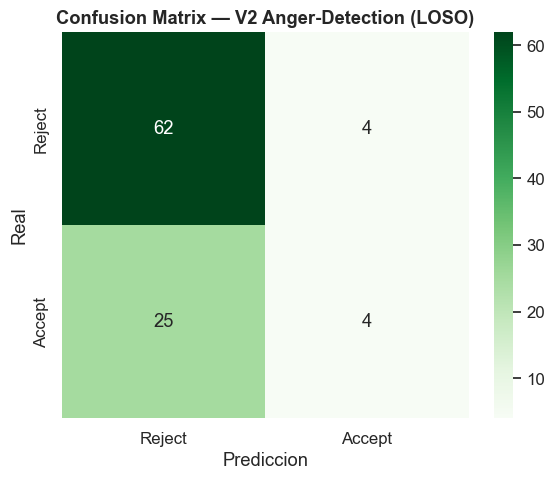

In [31]:
cm = confusion_matrix(y, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Reject','Accept'], yticklabels=['Reject','Accept'], ax=ax)
ax.set_xlabel('Prediccion'); ax.set_ylabel('Real')
ax.set_title(f'Confusion Matrix — V2 Anger-Detection (LOSO)', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix_v2.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
model_final = RandomForestClassifier(**HYPERPARAMS)
model_final.fit(X, y)

bundle = pickle.dumps({"preprocessor": preprocessor, "model": model_final,
                        "features": FEATURE_COLS, "hyperparams": HYPERPARAMS})
bundle_sha256 = sha256_bytes(bundle)
with open(OUTPUT_DIR / "model_v2.pkl", "wb") as f:
    f.write(bundle)
print(f"Bundle SHA-256: {bundle_sha256}")

Bundle SHA-256: 31a3fcba2ad49d49f1171ce437da1f0ca6dabbf6e7fa892bc633f31cb89ae872


### >>> REGISTRO ON-CHAIN: TRAINING <<<

In [33]:
train_payload = {
    "dataset_version": DATASET_VERSION,
    "model": "RandomForest",
    "hyperparams": HYPERPARAMS,
    "validation": "LOSO",
    "acc": round(metrics["accuracy"], 4),
    "f1": round(metrics["f1_macro"], 4),
    "auc": round(metrics["roc_auc"], 4) if metrics["roc_auc"] else None,
    "bundle_sha256": bundle_sha256,
}
print("Payload TRAINING:")
print(json_stable(train_payload))
print()
ALL_TX["training"] = safe_register(Stage.TRAINING, train_payload)

Payload TRAINING:
{"acc":0.6947,"auc":0.5047,"bundle_sha256":"31a3fcba2ad49d49f1171ce437da1f0ca6dabbf6e7fa892bc633f31cb89ae872","dataset_version":"V2_anger","f1":0.5133,"hyperparams":{"max_depth":4,"min_samples_leaf":1,"min_samples_split":2,"n_estimators":200,"n_jobs":-1,"random_state":42},"model":"RandomForest","validation":"LOSO"}

[web3] Sent tx: de4a42a8f42ee1ef3af7326e8df4d748bc04af69e2715cfc9f5e5f30378435f2
  [ON-CHAIN] OK | TX: de4a42a8f42ee1ef3af7326e8df4d748bc04af69e2715cfc9f5e5f30378435f2


---
## 4. SHAP — Explicabilidad

Misma configuración que V1: TreeExplainer, 80 background samples.

In [34]:
bg_size = min(80, X.shape[0])
bg_idx = np.random.RandomState(RANDOM_SEED).choice(X.shape[0], size=bg_size, replace=False)
background = X[bg_idx]
bg_sha256 = sha256_bytes(background.tobytes())

explainer = shap.TreeExplainer(model_final, data=background, feature_names=feature_names)
explanation = explainer(X)
sv = explanation.values
if sv.ndim == 3:
    sv = sv[:, :, 1]

mean_shap = np.abs(sv).mean(axis=0)
shap_order = np.argsort(mean_shap)[::-1]

print("SHAP Feature Importance — V2 Anger-Detection:")
print("=" * 60)
shap_ranking = []
for rank, idx in enumerate(shap_order, 1):
    pct = mean_shap[idx] / mean_shap.sum() * 100
    print(f"  {rank:2d}. {feature_names[idx]:30s} {mean_shap[idx]:.4f} ({pct:.1f}%)")
    shap_ranking.append({"feature": feature_names[idx], "mean_abs_shap": round(float(mean_shap[idx]), 6)})

SHAP Feature Importance — V2 Anger-Detection:
   1. hr_deceleration                0.0484 (21.1%)
   2. frontal_asymmetry              0.0385 (16.8%)
   3. delta_eeg_af7                  0.0338 (14.8%)
   4. delta_hr                       0.0335 (14.7%)
   5. gsr_change_pct                 0.0319 (14.0%)
   6. delta_rmssd                    0.0300 (13.1%)
   7. lf_hf_baseline                 0.0127 (5.5%)


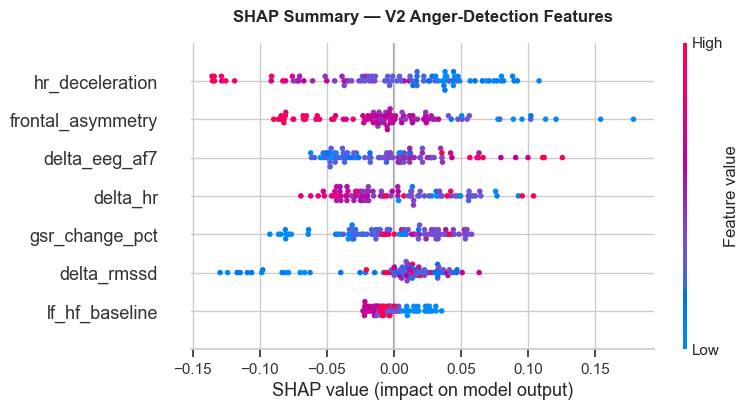

In [35]:
plt.figure(figsize=(12, 7))
shap.summary_plot(sv, X, feature_names=feature_names, show=False)
plt.title('SHAP Summary — V2 Anger-Detection Features', fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'shap_summary_v2.png', dpi=150, bbox_inches='tight')
plt.show()

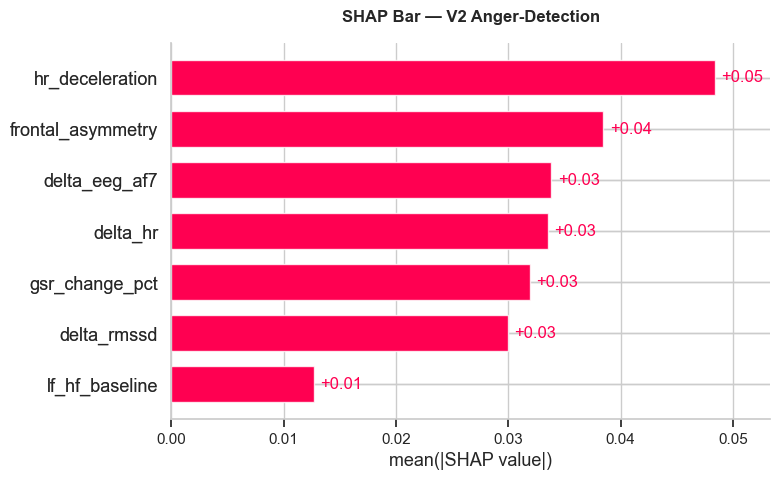

In [36]:
plt.figure(figsize=(10, 6))
shap.plots.bar(shap.Explanation(values=sv, data=X, feature_names=feature_names),
               max_display=12, show=False)
plt.title('SHAP Bar — V2 Anger-Detection', fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'shap_bar_v2.png', dpi=150, bbox_inches='tight')
plt.show()

### Tu interpretación — SHAP global

Observa los gráficos SHAP y responde:

1. ¿Cuáles son las features más importantes en tu modelo?
* Las dos features con mayor impacto son `hr_deceleration` (21.1%) y `frontal_asymmetry` (16.8%), 
seguidas por `delta_eeg_af7` , `delta_hr` , `gsr_change_pct` y `delta_rmssd` (entre 13-15%
cada una). La importancia está distribuida de forma relativamente uniforme entre las
primeras seis features y ninguna domina de forma clara. `lf_hf_baseline` es la excepción, tiene 5.5%, lo que sugiere que aporta poca información adicional para la predicción.

* El SHAP summary plot muestra que `hr_deceleration` con valores bajos (azul) lleva hacia
predict=accept, mientras que valores altos (rosa) lo llevan hacia reject, lo que es consistente con la
diferencia de medias observada en el EDA (accept=1.72 vs reject=5.71). Lo mismo sucede con `frontal_asymmetry` , valores negativos se asocian con accept, positivos con reject.

2. Comparando con el ejemplo 1: ahora que no hay `offer_amount`, ¿qué features toman su lugar?
* En V1,  `offer_amount` tenía el 61.4% de la importancia SHAP, por lo que todas las
features fisiológicas tenían roles marginales (≤5.5% cada una). Sin esa feature dominante, el modelo
V2 redistribuye la importancia entre múltiples señales fisiológicas, sin que ninguna alcance importancia comparable. Esto indica que la
información fisiológica disponible es débilmente discriminativa de forma individual, es necesario combinar varias señales para aproximar la predicción que `offer_amount` hacía por sí
sola. 


### >>> REGISTRO ON-CHAIN: EXPLAINABILITY_SETUP <<<

In [37]:
xai_payload = {
    "type": "TreeExplainer",
    "bg_n": bg_size,
    "bg_sha256": bg_sha256,
    "top5_features": [r["feature"] for r in shap_ranking[:5]],
    "top5_shap": [r["mean_abs_shap"] for r in shap_ranking[:5]],
}
print("Payload EXPLAINABILITY_SETUP:")
print(json_stable(xai_payload))
print()
ALL_TX["explainability"] = safe_register(Stage.EXPLAINABILITY_SETUP, xai_payload)

Payload EXPLAINABILITY_SETUP:
{"bg_n":80,"bg_sha256":"3675b7674c6a5481848ea4b69a6adda42d0f3f541fed7ba2b823e479942313fc","top5_features":["hr_deceleration","frontal_asymmetry","delta_eeg_af7","delta_hr","gsr_change_pct"],"top5_shap":[0.048388,0.038477,0.033845,0.033533,0.031946],"type":"TreeExplainer"}

[web3] Sent tx: 54f4ac9d15440dbb60d331e3fe0759d05e4f7ea88d23d8ef4b8d9676670451bf
  [ON-CHAIN] OK | TX: 54f4ac9d15440dbb60d331e3fe0759d05e4f7ea88d23d8ef4b8d9676670451bf


---
## 5. Waterfall — Casos individuales

Los waterfall plots muestran la contribución de cada feature para un trial específico.
Es la versión "local" de SHAP: en vez del ranking global, ves qué empujó la predicción
de ese caso en particular.



Reject correcto: P001 T02
  Real: reject | Pred: reject
    1. frontal_asymmetry             : -0.0752
    2. gsr_change_pct                : +0.0331
    3. delta_eeg_af7                 : -0.0325


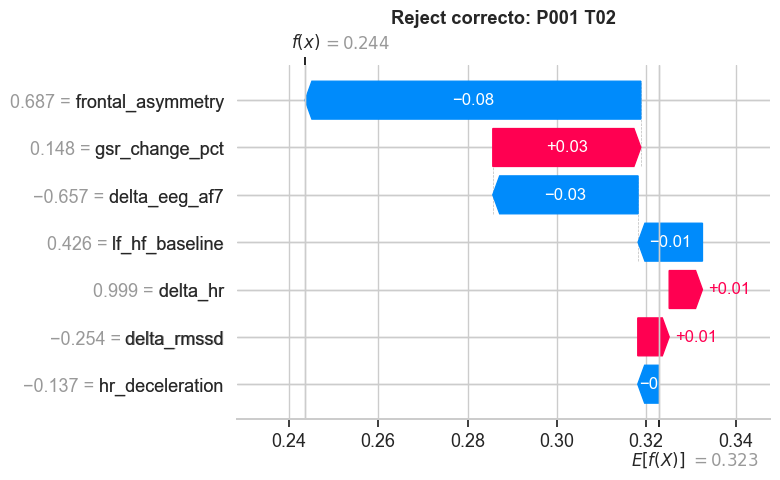


Accept correcto: P001 T08
  Real: accept | Pred: accept
    1. frontal_asymmetry             : +0.1542
    2. delta_eeg_af7                 : +0.1109
    3. delta_hr                      : +0.0424


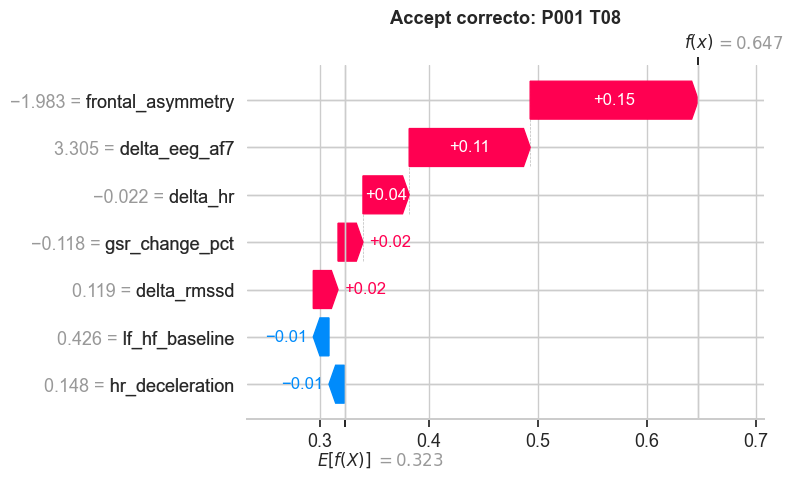


Misclassified: P001 T01
  Real: accept | Pred: reject
    1. delta_hr                      : +0.1041
    2. hr_deceleration               : +0.0818
    3. gsr_change_pct                : +0.0551


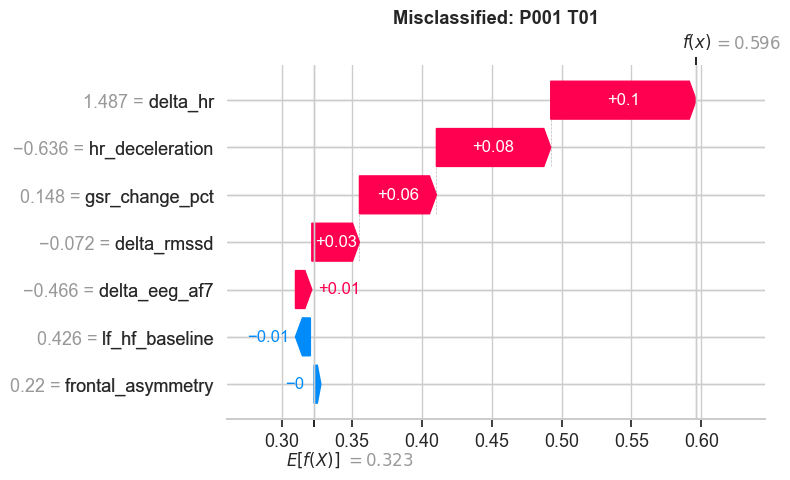

In [38]:
df["trial_number"] = df.groupby("participant_id").cumcount() + 1
correct_rej = np.where((y == 0) & (y_pred == 0))[0]
correct_acc = np.where((y == 1) & (y_pred == 1))[0]
misclass = np.where(y != y_pred)[0]


cases = {}
if len(correct_rej) > 0: cases["Reject correcto"] = correct_rej[0]
if len(correct_acc) > 0: cases["Accept correcto"] = correct_acc[0]
if len(misclass) > 0: cases["Misclassified"] = misclass[0]

for title, idx in cases.items():
    row = df.iloc[idx]
    sv_i = sv[idx]
    bv = explanation.base_values
    if hasattr(bv, '__len__'):
        bv_i = bv[idx, 1] if np.ndim(bv) > 1 and bv.shape[1] > 1 else (bv[idx] if np.ndim(bv) > 0 else float(bv))
    else:
        bv_i = float(bv)

    pred_label = 'accept' if y_pred[idx] == 1 else 'reject'
    print(f"\n{'='*50}")
    print(f"{title}: {row['participant_id']} T{int(row['trial_number']):02d}")
    print(f"  Real: {row['decision']} | Pred: {pred_label}")
    top3 = np.argsort(np.abs(sv_i))[::-1][:3]
    for r, fi in enumerate(top3, 1):
        print(f"    {r}. {feature_names[fi]:30s}: {sv_i[fi]:+.4f}")

    exp_i = shap.Explanation(values=sv_i, base_values=bv_i, data=X[idx], feature_names=feature_names)
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(exp_i, show=False, max_display=12)
    plt.title(f"{title}: {row['participant_id']} T{int(row['trial_number']):02d}", fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"waterfall_{title.lower().replace(' ','_')}.png", dpi=150, bbox_inches='tight')
    plt.show()

### Tu interpretación — Waterfall (V2)

Observa los waterfall plots de arriba:

1. En el caso **reject correcto**, ¿qué feature empujó más hacia el rechazo?
* **En el reject correcto (P001 T02), la feature que más empujó hacia el rechazo fue `frontal_asymmetry` (SHAP = −0.075).**
El modelo partió del valor base E[f(X)] = 0.323 y `frontal_asymmetry` lo empujó hacia reject. Algunas features empujaron un poco en sentido contrario, pero no fue suficiente para revertir la predicción.
2. Comparando con los waterfalls de V1: ¿las explicaciones por caso son más claras con features de anger-detection?
*En V1, los waterfalls son casi triviales de interpretar: `offer_amount` domina en los SHAP, y las demás features casi no aportan. La explicación es clara pero vacía desde el punto de vista fisiológico ya que el modelo simplemente aprendió que oferta baja implica rechazo.

* En V2, la explicación se distribuye entre varias features. En el accept correcto (P001 T08),
`frontal_asymmetry` y `delta_eeg_af7` cooperan para empujar hacia accept, lo que resulta en una explicación fisiológica mejor. 
Sin embargo, el caso mal clasificado muestra la debilidad del modelo, P001 T01 es un accept real donde `delta_hr` (+0.10) y `hr_deceleration` (+0.08) empujan hacia accept pero `frontal_asymmetry` ≈ 0 no aporta señal, y el modelo predice reject. 
En V1, el caso mal clasificado (P003 T10) ocurrió porque `offer_amount` era moderado (0.308) y las features fisiológicas no compensaron. 
En ambos modelos, los errores ocurren cuando las features dominantes no son informativas para ese trial específico; la diferencia es que V2 al menos distribuye el riesgo entre varias features.


---
## 6. Inferencia — 10 trials de muestra

In [39]:
def extract_shap_vector(explainer, x_row):
    exp = explainer(x_row)
    s = exp.values
    if s.ndim == 3: s = s[0, :, 1]
    elif s.ndim == 2: s = s[0, :]
    return s.astype(float)

n_infer = 10
sample_idx = np.random.RandomState(RANDOM_SEED).choice(len(df), size=n_infer, replace=False)
sample = df.iloc[sample_idx]

inference_results = []
print(f"Inferencia en {n_infer} trials:\n")

for i, (_, row) in enumerate(sample.iterrows()):
    x_vals = {col: float(row[col]) if pd.notna(row[col]) else 0.0 for col in FEATURE_COLS}
    x_df = pd.DataFrame([x_vals], columns=FEATURE_COLS)
    x_t = preprocessor.transform(x_df.values)
    prob = float(model_final.predict_proba(x_t)[0, 1])
    pred = int(prob >= 0.5)
    sv_i = extract_shap_vector(explainer, x_t)
    top_feat = feature_names[np.argmax(np.abs(sv_i))]

    pred_label = 'accept' if pred == 1 else 'reject'
    actual = row['decision']
    ok = 'OK' if pred_label == actual else 'MISS'
    print(f"  {i+1:2d}. {row['participant_id']} T{int(row['trial_number']):02d} | "
          f"real={actual:6s} pred={pred_label:6s} p={prob:.2f} [{ok}] top={top_feat}")

    inference_results.append({
        "pid": row['participant_id'], "trial": int(row['trial_number']),
        "actual": actual, "predicted": pred_label, "prob": prob,
        "top_feature": top_feat, "top_shap": float(sv_i[np.argmax(np.abs(sv_i))]),
    })

pd.DataFrame(inference_results).to_csv(OUTPUT_DIR / "inference_log_v2.csv", index=False)

Inferencia en 10 trials:

   1. P004 T21 | real=accept pred=accept p=0.54 [OK] top=delta_eeg_af7
   2. P001 T23 | real=accept pred=accept p=0.50 [OK] top=hr_deceleration
   3. P005 T02 | real=accept pred=reject p=0.39 [MISS] top=delta_hr
   4. P005 T03 | real=reject pred=reject p=0.17 [OK] top=hr_deceleration
   5. P001 T01 | real=accept pred=accept p=0.60 [OK] top=delta_hr
   6. P003 T03 | real=reject pred=reject p=0.26 [OK] top=delta_rmssd
   7. P003 T17 | real=accept pred=reject p=0.44 [MISS] top=hr_deceleration
   8. P003 T19 | real=accept pred=accept p=0.57 [OK] top=gsr_change_pct
   9. P001 T11 | real=reject pred=reject p=0.36 [OK] top=frontal_asymmetry
  10. P003 T22 | real=accept pred=reject p=0.48 [MISS] top=gsr_change_pct


### >>> REGISTRO ON-CHAIN: INFERENCE (batch) <<<

In [40]:
inference_summary = {
    "dataset_version": DATASET_VERSION,
    "n_inferences": n_infer,
    "accuracy_sample": sum(1 for r in inference_results if r['actual']==r['predicted']) / n_infer,
    "top_features_used": list(set(r['top_feature'] for r in inference_results)),
    "log_sha256": sha256_text(json_stable(inference_results)),
}
print("Payload INFERENCE:")
print(json_stable(inference_summary))
print()
ALL_TX["inference"] = safe_register(Stage.INFERENCE, inference_summary)

Payload INFERENCE:
{"accuracy_sample":0.7,"dataset_version":"V2_anger","log_sha256":"52b69d1f75f2391850fa598e7c4c7f947609c6b9ce6830029e88899631a79d38","n_inferences":10,"top_features_used":["delta_rmssd","delta_eeg_af7","hr_deceleration","delta_hr","frontal_asymmetry","gsr_change_pct"]}

[web3] Sent tx: bc9a6e529844d13bd3f20fb3adcd3fb906eb3bfb764ad126a29834bb0e111ee2
  [ON-CHAIN] OK | TX: bc9a6e529844d13bd3f20fb3adcd3fb906eb3bfb764ad126a29834bb0e111ee2


In [41]:
# Guardar artefactos
shap_df = pd.DataFrame(sv, columns=feature_names)
shap_df['participant_id'] = groups
shap_df['label'] = y
shap_df.to_csv(OUTPUT_DIR / 'shap_values_v2.csv', index=False)

summary = {
    "version": DATASET_VERSION, "metrics": metrics, "shap_ranking": shap_ranking,
    "transactions": {k: v for k, v in ALL_TX.items()},
}
with open(OUTPUT_DIR / 'results_v2.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)

print('=' * 60)
print(f'RESUMEN V2 (Anger-Detection Features)')
print('=' * 60)
print(f'  Accuracy:  {metrics["accuracy"]:.4f}')
print(f'  F1 macro:  {metrics["f1_macro"]:.4f}')
print(f'  AUC:       {metrics["roc_auc"]:.4f}' if metrics['roc_auc'] else '  AUC: N/A')
print(f'  Top SHAP:  {shap_ranking[0]["feature"]} ({shap_ranking[0]["mean_abs_shap"]:.4f})')
print(f'\n  TX registradas: {sum(1 for v in ALL_TX.values() if v)}/{len(ALL_TX)}')
print(f'\n  Archivos en {OUTPUT_DIR}:')
for p in sorted(OUTPUT_DIR.iterdir()):
    print(f'    {p.name} ({p.stat().st_size/1024:.1f} KB)')

print(f"\n{'='*60}")
print("Siguiente paso: comparar side-by-side con los resultados de tu equipo")
print("y con los de otros equipos via los registros on-chain.")

RESUMEN V2 (Anger-Detection Features)
  Accuracy:  0.6947
  F1 macro:  0.5133
  AUC:       0.5047
  Top SHAP:  hr_deceleration (0.0484)

  TX registradas: 4/4

  Archivos en output_v2_anger:
    confusion_matrix_v2.png (34.4 KB)
    dataset_v2_clean.csv (38.0 KB)
    inference_log_v2.csv (0.8 KB)
    model_v2.pkl (342.1 KB)
    results_v2.json (1.2 KB)
    shap_bar_v2.png (52.1 KB)
    shap_summary_v2.png (108.6 KB)
    shap_values_v2.csv (14.6 KB)
    waterfall_accept_correcto.png (65.5 KB)
    waterfall_misclassified.png (65.6 KB)
    waterfall_reject_correcto.png (67.2 KB)

Siguiente paso: comparar side-by-side con los resultados de tu equipo
y con los de otros equipos via los registros on-chain.


---
---
# PARTE 3 — Comparación V1 vs V2

Ahora que corriste ambos modelos, comparemos los resultados.


---
## 7. Comparación con el ejemplo 

La celda de abajo carga los resultados del ejemplo para comparar.


In [42]:
# Cargar resultados V1 si existen
v1_path = Path("output_v1_raw/results_v1.json")
if v1_path.exists():
    v1 = json.load(open(v1_path))
    v1_metrics = v1["metrics"]
    v1_shap = v1["shap_ranking"]

    print("COMPARACIÓN V1 (Raw) vs V2 (Anger-Detection)")
    print("=" * 65)
    print(f"{'Metrica':15s} {'V1 (Raw)':>12s} {'V2 (Anger)':>12s} {'Delta':>10s} {'Mejor':>8s}")
    print("-" * 65)
    for k in ["accuracy", "precision", "recall", "f1_macro", "roc_auc"]:
        v1v = v1_metrics.get(k)
        v2v = metrics.get(k)
        if v1v is not None and v2v is not None:
            delta = v2v - v1v
            mejor = "V2" if delta > 0 else "V1" if delta < 0 else "="
            print(f"  {k:13s} {v1v:12.4f} {v2v:12.4f} {delta:+10.4f} {mejor:>8s}")

    print(f"\nSHAP Ranking — Top 5:")
    print(f"{'Rank':>4s}  {'V1':30s} {'V2':30s}")
    print("-" * 70)
    for i in range(min(5, len(v1_shap), len(shap_ranking))):
        print(f"  {i+1:2d}.  {v1_shap[i]['feature']:30s} {shap_ranking[i]['feature']:30s}")
else:
    print("No se encontraron resultados de V1. Corre primero el notebook 08.")

COMPARACIÓN V1 (Raw) vs V2 (Anger-Detection)
Metrica             V1 (Raw)   V2 (Anger)      Delta    Mejor
-----------------------------------------------------------------
  accuracy            0.9474       0.6947    -0.2526       V1
  precision           1.0000       0.5000    -0.5000       V1
  recall              0.8276       0.1379    -0.6897       V1
  f1_macro            0.9346       0.5133    -0.4212       V1
  roc_auc             0.9687       0.5047    -0.4639       V1

SHAP Ranking — Top 5:
Rank  V1                             V2                            
----------------------------------------------------------------------
   1.  offer_amount                   hr_deceleration               
   2.  sdnn                           frontal_asymmetry             
   3.  hr_std                         delta_eeg_af7                 
   4.  rmssd                          delta_hr                      
   5.  mean_hr                        gsr_change_pct                


### Tu interpretación — Comparación con V1

Con los resultados de arriba, responde:

1. ¿Qué modelo tuvo mejor accuracy/F1? ¿Por cuánto?
* **V1 superó a V2 en todas las métricas por un margen amplio.** La diferencia en accuracy fue de 0.253 (0.947 vs 0.695), en F1-macro de 0.421 (0.935 vs 0.513) y en AUC de 0.464 (0.969 vs 0.505). El AUC de V2 en 0.505 es prácticamente indistinguible del azar, lo que indica que las features fisiológicas seleccionadas no logran separar clases de forma consistente entre participantes.
2. En V1,  `offer_amount` dominaba. ¿Qué features dominan en tu modelo?
* **En V2 no hay una feature dominante equivalente a `offer_amount` .** La importancia se distribuye entre `hr_deceleration` (21.1%),  `frontal_asymmetry` (16.8%),  `delta_eeg_af7` (14.8%),  `delta_hr` (14.7%) y `gsr_change_pct` (14.0%).
Ninguna es comparable  al 61.4% de `offer_amount` en V1.
3. ¿Las señales fisiológicas solas predicen mejor, peor, o similar que el primer modelo con todo?
* **Las señales fisiológicas solas predicen peor.** Sin embargo, esta comparación es algo injusta, ya que V1 incluye `offer_amount` , que es información directa sobre el estímulo que provoca la decisión. Un participante rechazará casi siempre ofertas bajas independientemente de su estado fisiológico.
V1 refleja la lógica económica, no una respuesta emocional. Que V2 sea peor se debe tanto a la dificultad del problema de clasificación como las limitaciones del dataset.
4. ¿Qué ventaja tiene un modelo basado solo en fisiología?
* **La ventaja de un modelo basado solo en fisiología es su independencia del contexto de la oferta.** Un modelo como V2 podría detectar los rechazos en situaciones donde la oferta no es conocida, por lo que tiene mayor potencial de generalización a otros contextos de toma de decisiones más allá del juego del ultimátum.
La limitación identificada aquí parece ser más un problema de tamaño de muestra más que un argumento contra un modelo que utilice únicamente señales fisiológicas.


---

## Conclusiones finales

En esta práctica se compararon dos modelos de clasificación de decisiones en el Juego del Ultimátum:
V1 con features crudas incluyendo el monto de la oferta, y V2 con features fisiológicas corregidas por baseline orientadas a la detección de enojo.

El resultado principal es que V1 no es un modelo de respuesta emocional sino uno que refleja la lógica económica. 
`offer_amount` concentró el 61.4% de la importancia SHAP, por lo que V1 aprendió esencialmente que ofertas bajas se rechazan, una regla que no requiere ninguna señal fisiológica.
Las features fisiológicas en V1 son marginales y probablemente capturan ruido, no respuesta emocional, ya que los valores absolutos sin corrección de baseline mezclan el estado basal del participante con la reacción al estímulo.

V2 aborda el problema más difícil, predecir la decisión exclusivamente desde la respuesta fisiológica.
Los resultados son modestos, AUC de 0.505, F1-macro de 0.513, pero su estructura es cualitativamente distinta. La importancia se distribuye entre varios features ( `hr_deceleration` , `frontal_asymmetry` , `delta_eeg_af7` ), y los waterfall plots muestran explicaciones que reflejan mejor las señales fisiológicas esperadas en las decisiones.

El bajo rendimiento de V2 se debe a limitaciones metodológicas, pues se cuenta sólo con 4 participantes y 95
trials, a partir de los cuales el modelo debe generalizar patrones fisiológicos a participantes no vistos con variabilidad interindividual alta. Este es un problema de tamaño de muestra, no un argumento en contra de un modelo basado en fisiología. El desbalance de clases, 70% reject, agrava el problema ya que el modelo tiende a predecir reject por defecto, teniendo un recall de accept de apenas 0.14.

Así, la práctica muestra que la comparación entre los modelos V1 y V2 refleja solamente cuánto ayuda conocer el monto de la oferta, no cuánto aportan las señales fisiológicas. Sería necesario un diseño experimental con mayor número de participantes para evaluar justamente el potencial predictivo de las señales de anger-detection.

---
